<a href="https://colab.research.google.com/github/Andrebenedetti16/Analise-de-Vendas-E-commerce-utilizando-Machine-Leraning/blob/novo_projeto/An%C3%A1lise_de_Vendas_por_Estado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

excel_file_path = pd.read_excel('/content/Funções Mercado de Trabalho - MEDIASES.xlsx')

display(excel_file_path)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,Vendedor,Idade,Estado,Valor,NaN,NaN,NaN
1,NaN,Lucas,27,RJ,117393,NaN,NaN,NaN
2,NaN,Ramiro,27,RJ,94887,NaN,Valor Médio,NaN
3,NaN,Antônio,31,MG,223554,NaN,RJ,148008.428571
4,NaN,Alfredo,29,SP,184726,NaN,SP,156110.750000
5,NaN,Brito,53,SP,256641,NaN,MG,171030.250000
6,NaN,Rodolpho,26,SP,86596,NaN,NaN,NaN
7,NaN,Luan,36,MG,90212,NaN,Idade Méda,NaN
8,NaN,Ana Claudia,42,RJ,199143,NaN,RJ,40.142857
9,NaN,Ana Maria,19,MG,180772,NaN,SP,38.250000


In [16]:
df_processed = excel_file_path.rename(columns= {'Unnamed: 3' : 'Estado', 'Unnamed: 4' : 'Valor'}).copy()
# Remove the first row which contains 'Estado', 'Valor' as data
df_processed = df_processed.iloc[1:].reset_index(drop=True)
# Convert 'Valor' column to numeric, coercing errors to NaN
df_processed['Valor'] = pd.to_numeric(df_processed['Valor'], errors='coerce')

df_melted = df_processed.melt(id_vars='Estado', value_vars=['Valor'], value_name='Vendas')

sales_by_state = df_melted.groupby('Estado')['Vendas'].sum()

print(sales_by_state)

Estado
MG     684121
RJ    1036059
SP     624443
Name: Vendas, dtype: int64


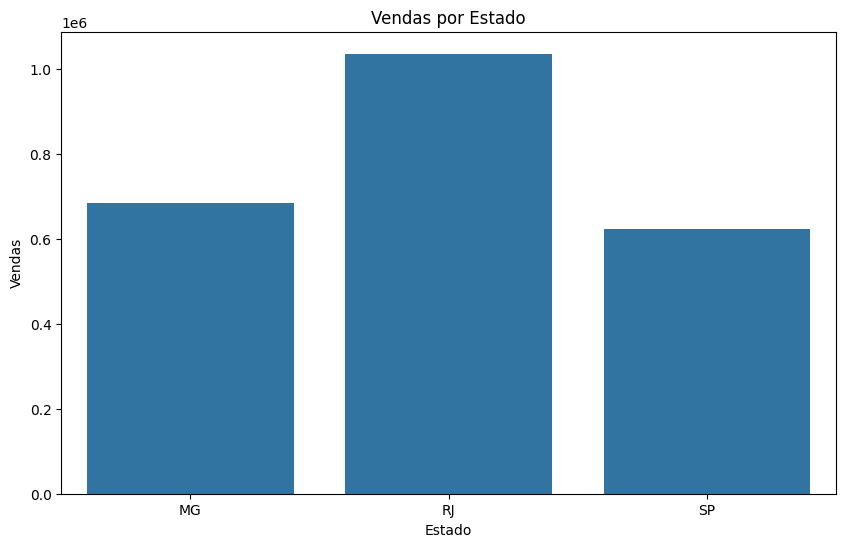

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_state.index, y=sales_by_state.values)
plt.xlabel('Estado')
plt.ylabel('Vendas')
plt.title('Vendas por Estado')
plt.show()